In [1]:
from google.colab import drive, files
drive.mount('/content/gdrive/')

import os
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis"
os.chdir(PROJECT_FOLDER)
print("Current dir: ", os.getcwd())

Mounted at /content/gdrive/
Current dir:  /content/gdrive/MyDrive/Colab Notebooks/Thesis/Sentiment Analysis


In [2]:
import pandas as pd
data = pd.read_csv("AMZN_BERT_SCORE_READY_FOR_TRAINING.csv")
seed = 412
data.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,Bert_Label,Bert_Score
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",neutral,0.666194
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",negative,0.911996
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",negative,0.434760
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",positive,0.639022
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",positive,0.608427


In [3]:
data['Bert_Label'] = data['Bert_Label'].replace({'neutral':0.5, 'negative':0, 'positive':1})
data.head()

<ipython-input-3-ab3eb056249a>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Bert_Label'] = data['Bert_Label'].replace({'neutral':0.5, 'negative':0, 'positive':1})


,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,Bert_Label,Bert_Score
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.5,0.666194
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.0,0.911996
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.0,0.434760
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",1.0,0.639022
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",1.0,0.608427


# **Training with BERT_SCORE and Closing**

In [4]:
days = 60

In [5]:
amzn_data = data[['Close','Bert_Score']]
amzn_data.head()

,Close,Bert_Score
0,159.524506,0.666194
1,161.195496,0.911996
2,157.597000,0.434760
3,158.073502,0.639022
4,161.145004,0.608427


Checking for negative values in order to adjust the min max scaler

In [6]:
print(amzn_data['Bert_Score'].min())

0.3417164981365204


In [7]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[159.52450562   0.66619354]
 [161.19549561   0.91199577]
 [157.59700012   0.4347603 ]
 ...
 [188.71000671   0.50964153]
 [192.08000183   0.90277892]
 [193.05999756   0.8153981 ]]


In [8]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [9]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[159.52450562   0.66619354]
 [161.19549561   0.91199577]
 [157.59700012   0.4347603 ]
 ...
 [180.83000183   0.83806461]
 [179.8500061    0.81723231]
 [182.5          0.80950516]]


<class 'numpy.ndarray'>


In [ ]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler(feature_range=(0,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-10-24d359190417>", line 1, in <cell line: 0>
    from sklearn.preprocessing import MinMaxScaler
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1138, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 1078, in _find_spec
  File "<frozen importlib._bootstrap_external>", line 1507, in find_spec
  File "<frozen importlib._bootstrap_external>", line 1476, in _get_spec
  File "<frozen importlib._bootstrap_external>", line 1434, in _path_importer_cache
OSError: [Errno 107] Transport endpoint is not connected

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py",

In [ ]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 2)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 2)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 2)
Test inputs with a reshape : (257, 2)
Test inputs after transformed : (257, 2)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [ ]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 2)
(725, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],2))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 2)
725
60


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],2))
print(X_test.shape)

(197, 60, 2)
(197, 60, 2)


In [ ]:
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dropout, Activation, Dense
model1 = Sequential()
model1.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 2), activation='tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model1.add(Dropout(0.2))
model1.add(LSTM(units = 100, activation='tanh'))
model1.add(Dropout(0.2))
model1.add(Dense(units=1))
model1.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model1.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        41,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,501 (1.08 MB)

 Trainable params: 282,501 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(seed)
tf.random.set_seed(seed)
history1 = model1.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.1170 - mae: 0.2607
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0151 - mae: 0.0957
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0105 - mae: 0.0796
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0085 - mae: 0.0728
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0081 - mae: 0.0703
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0079 - mae: 0.0702
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0072 - mae: 0.0671
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0078 - mae: 0.0670
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0076 - mae: 0.0668
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0087 - mae: 0.0731
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0064 - mae: 0.0619
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0072 - mae: 0.0659
Epoch 13/300
23/23 ━━━━━━

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], label='Training Loss')
plt.title('Model Loss Closing with Bert Score')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history1.history['mae'], label='Training MAE')
plt.title('Model Loss Closing with Bert Score')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()


In [ ]:
predictions = model1.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 1))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [ ]:
rmse1 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse1)

3.0184989315449875


Creating a dates dataframe for visualization

In [ ]:
dates = data['Date']

<ipython-input-27-9a56ff2dece3>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Date'] = dates[:amzn_len]
<ipython-input-27-9a56ff2dece3>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing['Date'] = dates[amzn_len:]
<ipython-input-27-9a56ff2dece3>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

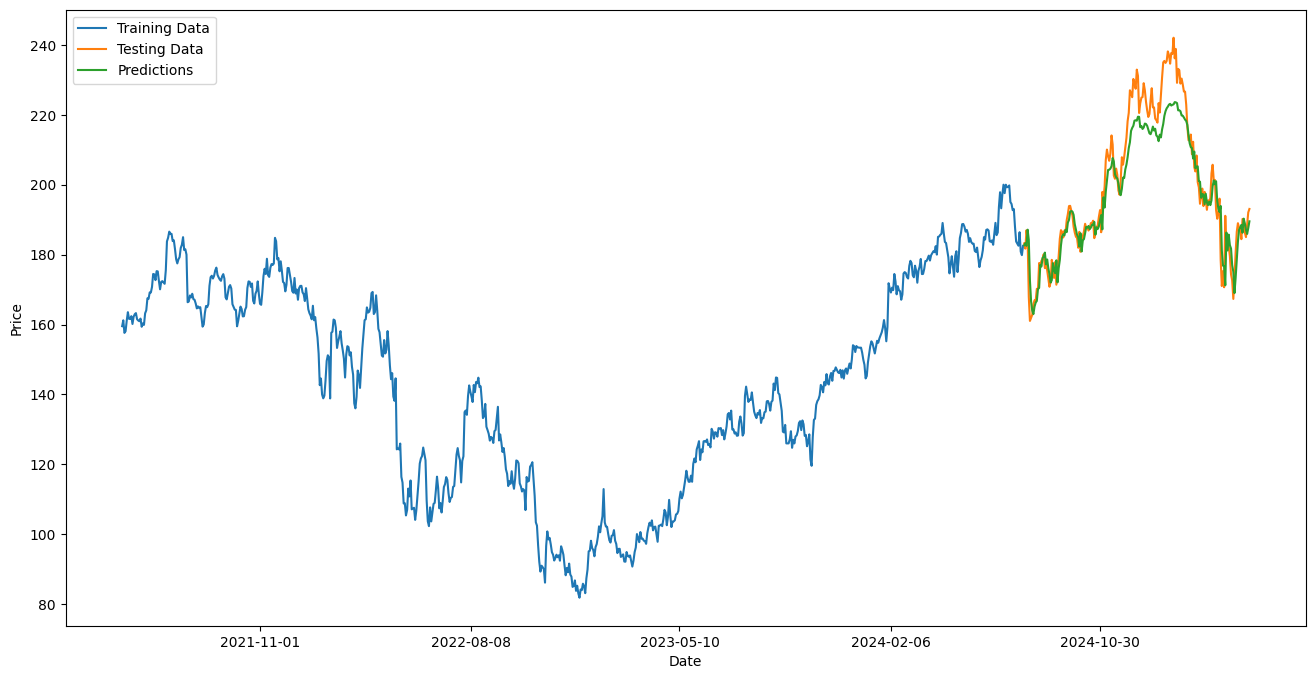

In [ ]:
train = amzn_data[:amzn_len]
train['Date'] = dates[:amzn_len]
testing = amzn_data[amzn_len:]
testing['Date'] = dates[amzn_len:]
testing['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train['Date'],train['Close'], label = "Training Data")
plt.plot(testing['Date'],testing['Close'], label = "Testing Data")
plt.plot(testing['Date'], testing['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing.head(10)

,Close,Bert_Score,Date,Predictions
785,183.199997,0.913264,2024-07-29,182.699268
786,181.710007,0.970124,2024-07-30,183.221347
787,186.979996,0.934309,2024-07-31,182.502506
788,184.070007,0.951828,2024-08-01,187.132000
789,167.899994,0.930361,2024-08-02,184.216034
790,161.020004,0.940028,2024-08-05,172.543696
791,161.929993,0.565676,2024-08-06,166.616091
792,162.770004,0.930589,2024-08-07,163.989488
793,165.800003,0.711428,2024-08-08,162.968470
794,166.940002,0.936552,2024-08-09,165.116928


# **Modeling with Bert Label and Closing Price**

In [ ]:
amzn_data = data[['Close','Bert_Label']]
amzn_data.head()

,Close,Bert_Label
0,159.524506,0.5
1,161.195496,0.0
2,157.597000,0.0
3,158.073502,1.0
4,161.145004,1.0


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[159.52450562   0.5       ]
 [161.19549561   0.        ]
 [157.59700012   0.        ]
 ...
 [188.71000671   0.5       ]
 [192.08000183   1.        ]
 [193.05999756   0.5       ]]


In [ ]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [ ]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[159.52450562   0.5       ]
 [161.19549561   0.        ]
 [157.59700012   0.        ]
 ...
 [180.83000183   0.        ]
 [179.8500061    0.5       ]
 [182.5          1.        ]]


<class 'numpy.ndarray'>


In [ ]:
x_scaler = MinMaxScaler(feature_range=(0,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[0.65750978 0.5       ]
 [0.67164914 0.        ]
 [0.64119987 0.        ]
 ...
 [0.83778983 0.        ]
 [0.82949743 0.5       ]
 [0.8519208  1.        ]]


(785, 2)


In [ ]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 2)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 2)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 2)
Test inputs with a reshape : (257, 2)
Test inputs after transformed : (257, 2)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [ ]:
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 2)
(725, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],2))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 2)
725
60


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],2))
print(X_test.shape)

(197, 60, 2)
(197, 60, 2)


In [ ]:
model2 = Sequential()
model2.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 2), activation='tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model2.add(Dropout(0.2))
model2.add(LSTM(units = 100, activation='tanh'))
model2.add(Dropout(0.2))
model2.add(Dense(units=1))
model2.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model2.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 100)        │        41,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,501 (1.08 MB)

 Trainable params: 282,501 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(seed)
tf.random.set_seed(seed)
history2 = model2.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.1036 - mae: 0.2433
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0128 - mae: 0.0876
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0087 - mae: 0.0732
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0091 - mae: 0.0737
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0073 - mae: 0.0670
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0074 - mae: 0.0672
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0071 - mae: 0.0668
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0071 - mae: 0.0659
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0084 - mae: 0.0703
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0092 - mae: 0.0760
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0062 - mae: 0.0606
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0062 - mae: 0.0615
Epoch 13/300
23/23 ━━━━━━

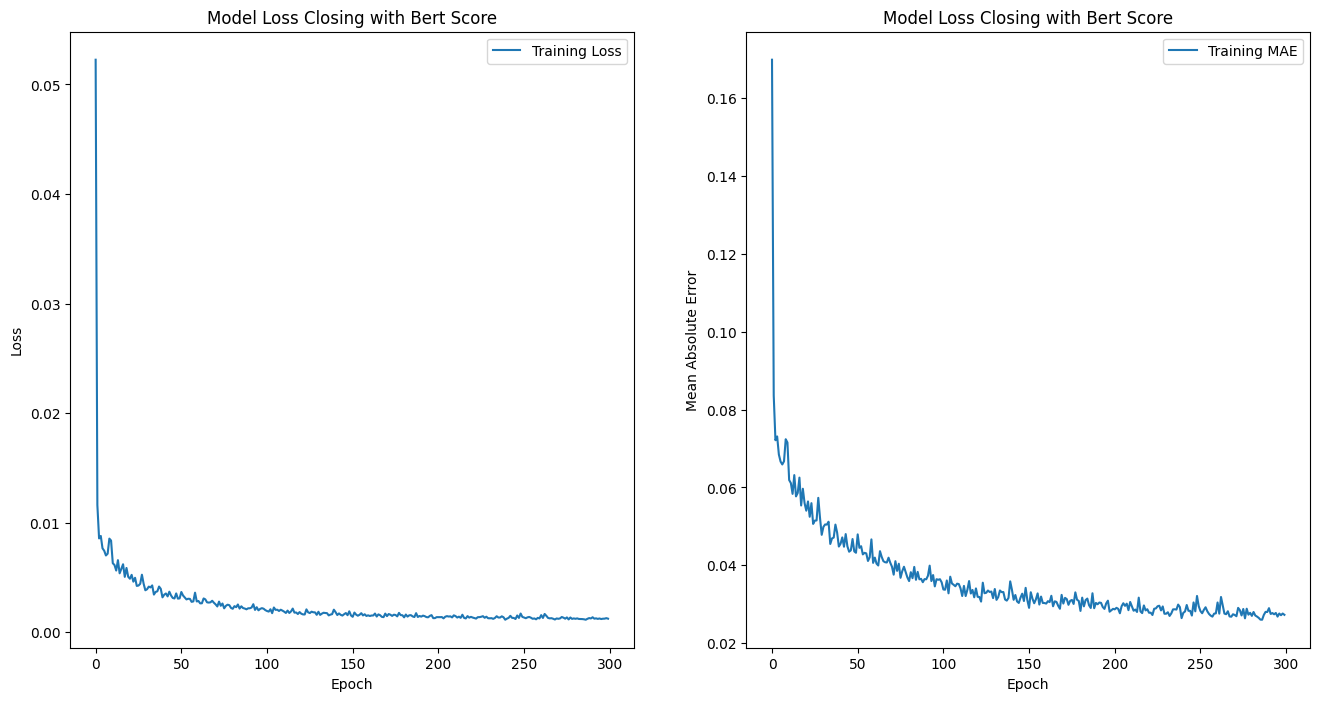

In [ ]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'], label='Training Loss')
plt.title('Model Loss Closing with Bert Score')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history2.history['mae'], label='Training MAE')
plt.title('Model Loss Closing with Bert Score')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()

In [ ]:
predictions = model2.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 1))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step


In [ ]:
rmse2 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse2)

10.523797176242795


<ipython-input-46-915aa82fc5c5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train2['Date'] = dates[:amzn_len]
<ipython-input-46-915aa82fc5c5>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing2['Date'] = dates[amzn_len:]
<ipython-input-46-915aa82fc5c5>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

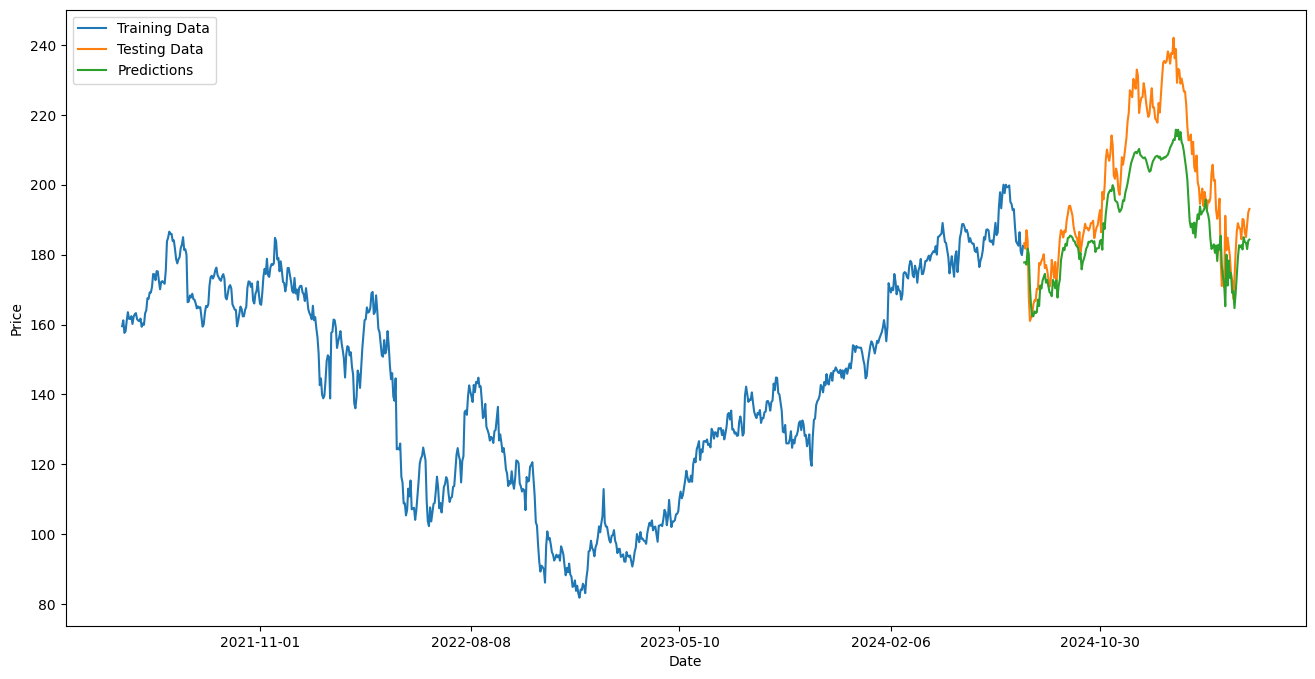

In [ ]:
train2 = amzn_data[:amzn_len]
train2['Date'] = dates[:amzn_len]
testing2 = amzn_data[amzn_len:]
testing2['Date'] = dates[amzn_len:]
testing2['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train2['Date'],train2['Close'], label = "Training Data")
plt.plot(testing2['Date'],testing2['Close'], label = "Testing Data")
plt.plot(testing2['Date'], testing2['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

# **Model 3 with Bert Labels and scores**

In [ ]:
amzn_data = data[['Close','Bert_Label','Bert_Score']]
amzn_data.head()

,Close,Bert_Label,Bert_Score
0,159.524506,0.5,0.666194
1,161.195496,0.0,0.911996
2,157.597000,0.0,0.434760
3,158.073502,1.0,0.639022
4,161.145004,1.0,0.608427


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[159.52450562   0.5          0.66619354]
 [161.19549561   0.           0.91199577]
 [157.59700012   0.           0.4347603 ]
 ...
 [188.71000671   0.5          0.50964153]
 [192.08000183   1.           0.90277892]
 [193.05999756   0.5          0.8153981 ]]


In [ ]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [ ]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[159.52450562   0.5          0.66619354]
 [161.19549561   0.           0.91199577]
 [157.59700012   0.           0.4347603 ]
 ...
 [180.83000183   0.           0.83806461]
 [179.8500061    0.5          0.81723231]
 [182.5          1.           0.80950516]]


<class 'numpy.ndarray'>


In [ ]:
x_scaler = MinMaxScaler(feature_range=(0,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[0.65750978 0.5        0.51476589]
 [0.67164914 0.         0.90471829]
 [0.64119987 0.         0.14760914]
 ...
 [0.83778983 0.         0.78743036]
 [0.82949743 0.5        0.75438101]
 [0.8519208  1.         0.74212229]]


(785, 3)


In [ ]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 3)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 3)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 3)
Test inputs with a reshape : (257, 3)
Test inputs after transformed : (257, 3)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [ ]:
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 3)
(725, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],3))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 3)
725
60


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],3))
print(X_test.shape)

(197, 60, 3)
(197, 60, 3)


In [ ]:
model3 = Sequential()
model3.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 3), activation='tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model3.add(Dropout(0.2))
model3.add(LSTM(units = 100, activation='tanh'))
model3.add(Dropout(0.2))
model3.add(Dense(units=1))
model3.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model3.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 100)        │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,901 (1.08 MB)

 Trainable params: 282,901 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(seed)
tf.random.set_seed(seed)
history3 = model3.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0987 - mae: 0.2349
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0112 - mae: 0.0855
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0095 - mae: 0.0762
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0080 - mae: 0.0684
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0081 - mae: 0.0710
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0089 - mae: 0.0723
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0074 - mae: 0.0668
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0071 - mae: 0.0653
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0089 - mae: 0.0732
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0067 - mae: 0.0641
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0063 - mae: 0.0626
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0076 - mae: 0.0684
Epoch 13/300
23/23 ━━━━━━

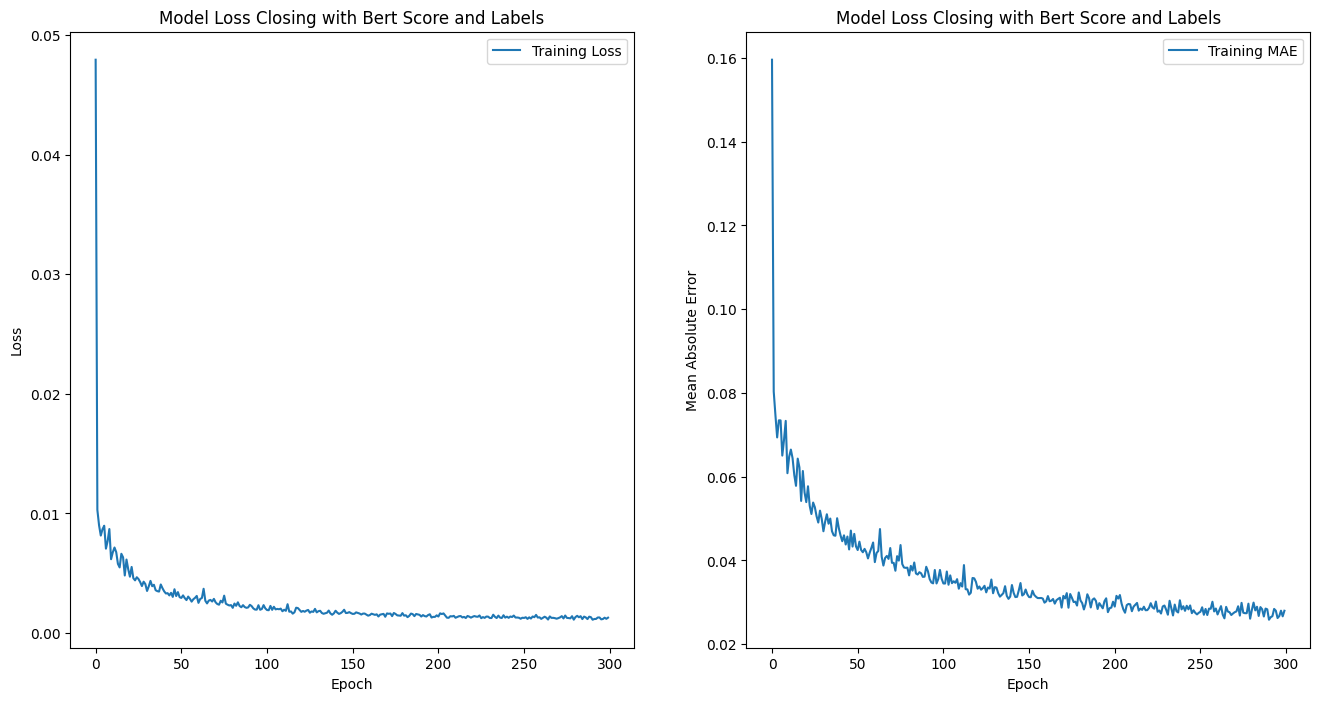

In [ ]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.plot(history3.history['loss'], label='Training Loss')
plt.title('Model Loss Closing with Bert Score and Labels')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history3.history['mae'], label='Training MAE')
plt.title('Model Loss Closing with Bert Score and Labels')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()

In [ ]:
predictions = model3.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 2))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step


In [ ]:
rmse3 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse3)

6.3972263344973115


<ipython-input-65-8fc52feac779>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train3['Date'] = dates[:amzn_len]
<ipython-input-65-8fc52feac779>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing3['Date'] = dates[amzn_len:]
<ipython-input-65-8fc52feac779>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

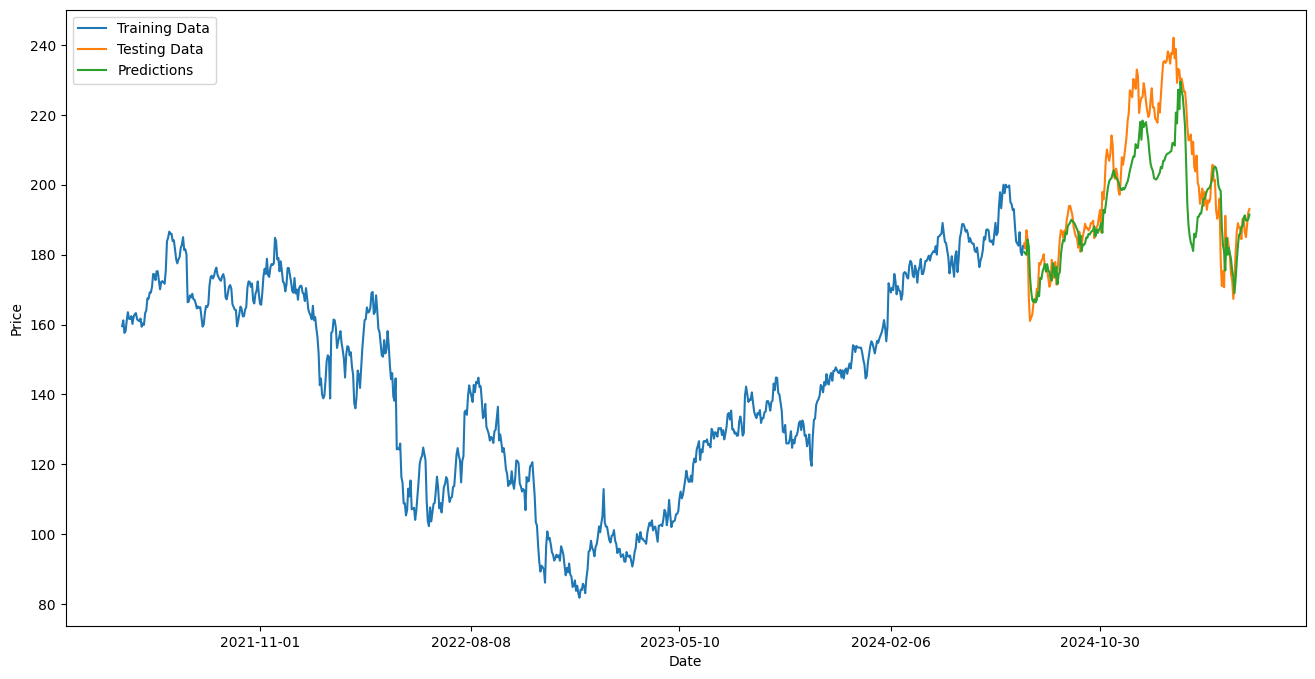

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
train3 = amzn_data[:amzn_len]
train3['Date'] = dates[:amzn_len]
testing3 = amzn_data[amzn_len:]
testing3['Date'] = dates[amzn_len:]
testing3['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train3['Date'],train3['Close'], label = "Training Data")
plt.plot(testing3['Date'],testing3['Close'], label = "Testing Data")
plt.plot(testing3['Date'], testing3['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

# **New Model 4**

In [ ]:
data['Bert_Sentiment'] = data['Bert_Label'] * data['Bert_Score']
data['Bert_Sentiment']

,Bert_Sentiment
0,0.333097
1,0.000000
2,0.000000
3,0.639022
4,0.608427
...,...
977,0.000000
978,0.661777
979,0.254821
980,0.902779


In [ ]:
amzn_data = data[['Close','Bert_Sentiment']]
amzn_data.head()

,Close,Bert_Sentiment
0,159.524506,0.333097
1,161.195496,0.000000
2,157.597000,0.000000
3,158.073502,0.639022
4,161.145004,0.608427


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[159.52450562   0.33309677]
 [161.19549561   0.        ]
 [157.59700012   0.        ]
 ...
 [188.71000671   0.25482076]
 [192.08000183   0.90277892]
 [193.05999756   0.40769905]]


In [ ]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [ ]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[159.52450562   0.33309677]
 [161.19549561   0.        ]
 [157.59700012   0.        ]
 ...
 [180.83000183   0.        ]
 [179.8500061    0.40861616]
 [182.5          0.80950516]]


<class 'numpy.ndarray'>


In [ ]:
x_scaler = MinMaxScaler(feature_range=(0,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[0.65750978 0.35136898]
 [0.67164914 0.        ]
 [0.64119987 0.        ]
 ...
 [0.83778983 0.        ]
 [0.82949743 0.43103102]
 [0.8519208  0.85391102]]


(785, 2)


In [ ]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 2)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 2)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 2)
Test inputs with a reshape : (257, 2)
Test inputs after transformed : (257, 2)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [ ]:
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 2)
(725, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],2))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 2)
725
60


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],2))
print(X_test.shape)

(197, 60, 2)
(197, 60, 2)


In [ ]:
model4 = Sequential()
model4.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 2), activation='tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model4.add(Dropout(0.2))
model4.add(LSTM(units = 100, activation='tanh'))
model4.add(Dropout(0.2))
model4.add(Dense(units=1))
model4.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model4.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 60, 100)        │        41,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,501 (1.08 MB)

 Trainable params: 282,501 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(seed)
tf.random.set_seed(seed)
history4 = model4.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1096 - mae: 0.2383
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0089 - mae: 0.0766
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0087 - mae: 0.0721
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0086 - mae: 0.0724
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0070 - mae: 0.0659
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0090 - mae: 0.0747
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0082 - mae: 0.0721
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0080 - mae: 0.0708
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0055 - mae: 0.0594
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0066 - mae: 0.0631
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0073 - mae: 0.0677
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0057 - mae: 0.0586
Epoch 13/300
23/23 ━━━━━━

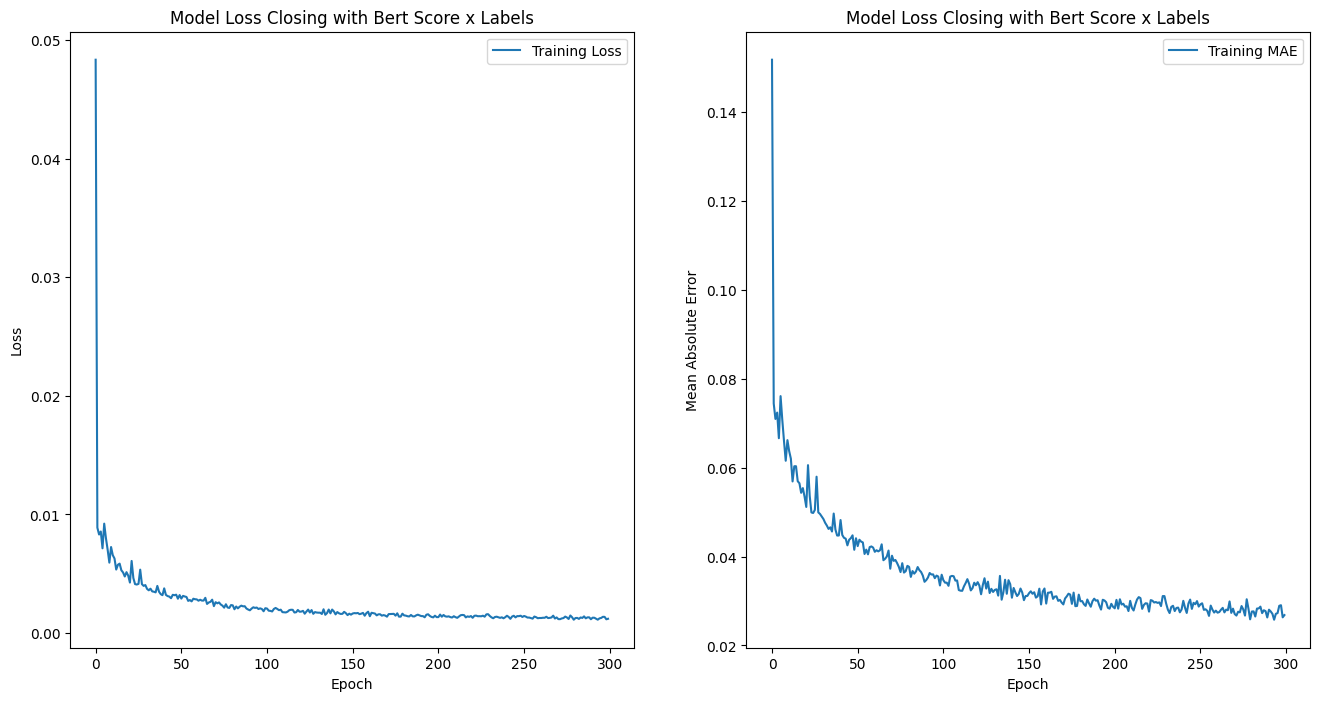

In [ ]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.plot(history4.history['loss'], label='Training Loss')
plt.title('Model Loss Closing with Bert Score x Labels')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history4.history['mae'], label='Training MAE')
plt.title('Model Loss Closing with Bert Score x Labels')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()

In [ ]:
predictions = model4.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 1))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


In [ ]:
rmse4 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse4)

5.619054783354


<ipython-input-87-171db33b67b2>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train4['Date'] = dates[:amzn_len]
<ipython-input-87-171db33b67b2>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing4['Date'] = dates[amzn_len:]
<ipython-input-87-171db33b67b2>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

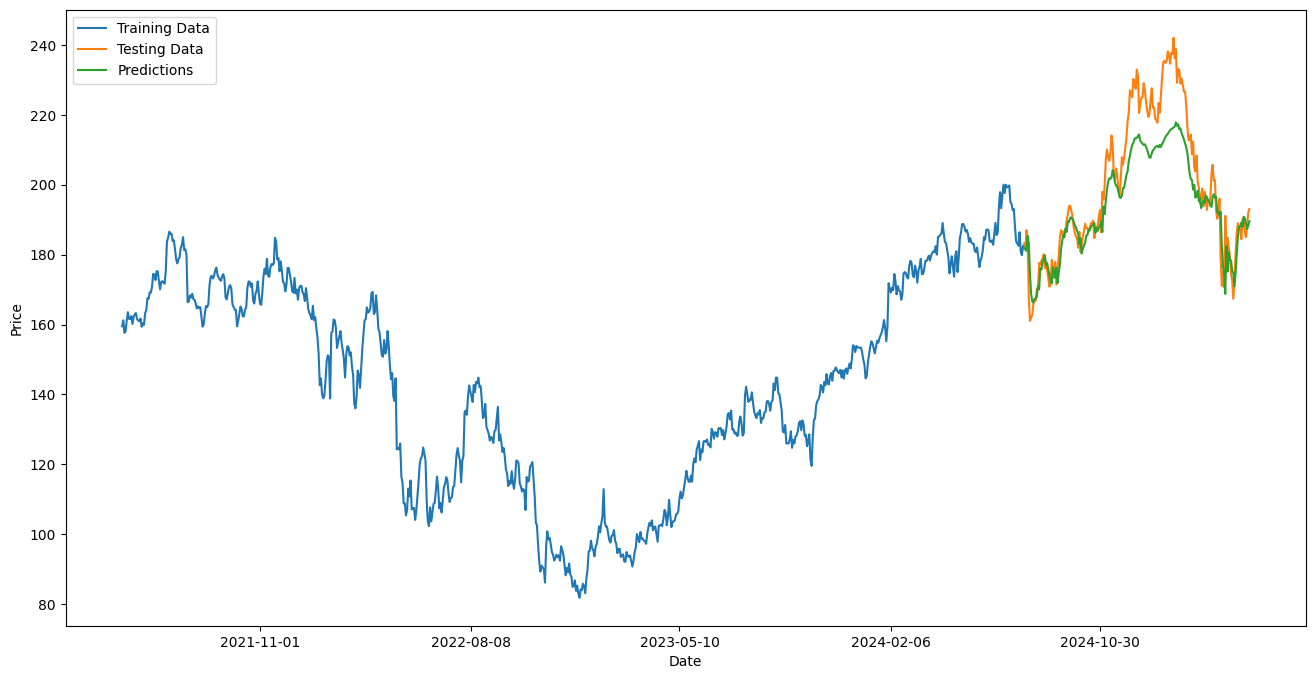

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
train4 = amzn_data[:amzn_len]
train4['Date'] = dates[:amzn_len]
testing4 = amzn_data[amzn_len:]
testing4['Date'] = dates[amzn_len:]
testing4['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train4['Date'],train4['Close'], label = "Training Data")
plt.plot(testing4['Date'],testing4['Close'], label = "Testing Data")
plt.plot(testing4['Date'], testing4['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
testing4.head(15)

,Close,Bert_Sentiment,Date,Predictions
785,183.199997,0.000000,2024-07-29,181.955935
786,181.710007,0.000000,2024-07-30,181.450600
787,186.979996,0.934309,2024-07-31,181.064528
788,184.070007,0.000000,2024-08-01,185.361288
789,167.899994,0.000000,2024-08-02,183.280264
790,161.020004,0.000000,2024-08-05,174.766701
791,161.929993,0.282838,2024-08-06,168.838272
792,162.770004,0.930589,2024-08-07,166.551806
793,165.800003,0.355714,2024-08-08,166.316619
794,166.940002,0.000000,2024-08-09,167.342321


# **Closing Price with Difference and Bert Score**

In [ ]:
data['Close_Difference'] = ""
for i in range(len(data['Close'])):
  try:
    data['Close_Difference'].iloc[i] = data['Close'].iloc[i] - data['Close'].iloc[i-1]
  except IndexError:
    continue
data['Close_Difference'].iloc[0] = -5.05549
data.head()

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Close_Difference'].iloc[i] = data['Close'].iloc[i] - data['Close'].iloc[i-1]
<ipython-input-5-db7f3a9870a3>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Close_Difference'].iloc[i] = data['Close'].iloc[i] - data['Close'].iloc[i-1]
<ipython-input-5-db7f3a9870a3>:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate

,Unnamed: 0,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,article-title,Bert_Label,Bert_Score,Close_Difference
0,0,2021-05-10,164.115997,164.149994,159.500000,159.524506,116772000,0.0,0.0,"""'Formula One great to develop electric vans, ...",0.5,0.666194,-5.05549
1,1,2021-05-11,156.813995,161.899994,156.368500,161.195496,92396000,0.0,0.0,"""'Washington Post names Sally Buzbee first wom...",0.0,0.911996,1.67099
2,2,2021-05-12,159.250000,160.397003,156.654999,157.597000,98728000,0.0,0.0,"""'Sonos boosts sales outlook despite global ch...",0.0,0.434760,-3.598495
3,3,2021-05-13,159.273499,160.192001,156.649994,158.073502,67018000,0.0,0.0,"""'Amazon seeks renewable power for Japan data ...",1.0,0.639022,0.476501
4,4,2021-05-14,159.278000,161.442993,159.149994,161.145004,66500000,0.0,0.0,"""'Less than 3% of U.S. small businesses could ...",1.0,0.608427,3.071503


In [ ]:
amzn_data = data[['Close','Close_Difference', 'Bert_Score']]
amzn_data.head()

,Close,Close_Difference,Bert_Score
0,159.524506,-5.05549,0.666194
1,161.195496,1.67099,0.911996
2,157.597000,-3.598495,0.434760
3,158.073502,0.476501,0.639022
4,161.145004,3.071503,0.608427


In [ ]:
amzn_data_array = amzn_data.values
print(amzn_data_array)

[[159.52450561523438 -5.05549 0.6661935448646545]
 [161.19549560546875 np.float64(1.670989990234375) 0.911995768547058]
 [157.5970001220703 np.float64(-3.5984954833984375) 0.4347603023052215]
 ...
 [188.7100067138672 np.float64(3.700012207031193) 0.5096415281295776]
 [192.0800018310547 np.float64(3.3699951171875) 0.9027789235115052]
 [193.0599975585937 np.float64(0.9799957275390057) 0.815398097038269]]


In [ ]:
amzn_len = int(len(amzn_data_array) *0.8)
print(amzn_len)

785


In [ ]:
training_data = amzn_data_array[0:amzn_len]
print(training_data)
print('\n')
print(type(training_data))

[[159.52450561523438 -5.05549 0.6661935448646545]
 [161.19549560546875 np.float64(1.670989990234375) 0.911995768547058]
 [157.5970001220703 np.float64(-3.5984954833984375) 0.4347603023052215]
 ...
 [180.8300018310547 np.float64(-5.580001831054602) 0.8380646109580994]
 [179.85000610351562 np.float64(-0.9799957275390625) 0.8172323107719421]
 [182.5 np.float64(2.649993896484375) 0.8095051646232605]]


<class 'numpy.ndarray'>


In [ ]:
from sklearn.preprocessing import MinMaxScaler
x_scaler = MinMaxScaler(feature_range=(-1,1))
training_data_scaled = x_scaler.fit_transform(training_data)
print(training_data_scaled)
print("\n")
print(training_data_scaled.shape)

[[ 0.31501956 -0.21964201  0.02953178]
 [ 0.34329829  0.12434441  0.80943657]
 [ 0.28239973 -0.14513256 -0.70478173]
 ...
 [ 0.67557966 -0.2464651   0.57486073]
 [ 0.65899486 -0.01122473  0.50876202]
 [ 0.7038416   0.17440983  0.48424459]]


(785, 3)


In [ ]:
test = amzn_data_array[amzn_len:]
print(test.shape)

(197, 3)


In [ ]:
test_inputs = amzn_data_array[len(amzn_data) - len(test) - days : ]
print(f"Test inputs without a reshape : {test_inputs.shape}")
test_inputs = test_inputs.reshape(-1, 3)
print(f"Test inputs with a reshape : {test_inputs.shape}")
test_inputs = x_scaler.transform(test_inputs)
print(f"Test inputs after transformed : {test_inputs.shape}")

Test inputs without a reshape : (257, 3)
Test inputs with a reshape : (257, 3)
Test inputs after transformed : (257, 3)


In [ ]:
X_train = []
y_train = []


for i in range(days, len(training_data_scaled)):
  X_train.append(training_data_scaled[i - days: i,:])
  y_train.append(training_data_scaled[i:i+1, 0])
  if i <= days:
    print(f"These values are smaller than the {days} day minimum")

print(type(X_train))
print(type(y_train))

These values are smaller than the 60 day minimum
<class 'list'>
<class 'list'>


In [ ]:
import numpy as np
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape)
print(y_train.shape)

(725, 60, 3)
(725, 1)


In [ ]:
X_test = []
y_test = amzn_data_array[amzn_len:, 0]
for i in range(days, test_inputs.shape[0]):
  X_test.append(test_inputs[i- days: i, :])

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],3))
print(X_train.shape)
print(X_train.shape[0])
print(X_train.shape[1])

(725, 60, 3)
725
60


In [ ]:
X_test = np.array(X_test)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],3))
print(X_test.shape)

(197, 60, 3)
(197, 60, 3)


In [ ]:
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dropout, Activation, Dense
model5 = Sequential()
model5.add(LSTM(units = 100, return_sequences= True, input_shape = (X_train.shape[1], 3), activation='tanh'))
model5.add(Dropout(0.2))
model5.add(LSTM(units = 100, return_sequences=True, activation='tanh'))
model5.add(Dropout(0.2))
model5.add(LSTM(units=100, return_sequences=True, activation = 'tanh'))
model5.add(Dropout(0.2))
model5.add(LSTM(units = 100, activation='tanh'))
model5.add(Dropout(0.2))
model5.add(Dense(units=1))
model5.compile(optimizer='adam', loss = 'mean_squared_error', metrics = ['mae'])
model5.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 60, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,901 (1.08 MB)

 Trainable params: 282,901 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
np.random.seed(seed)
tf.random.set_seed(seed)
history5 = model5.fit(X_train, y_train, epochs = 300, batch_size = 32)

Epoch 1/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.1070 - mae: 0.2517
Epoch 2/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0254 - mae: 0.1238
Epoch 3/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0177 - mae: 0.1032
Epoch 4/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0161 - mae: 0.0986
Epoch 5/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0142 - mae: 0.0927
Epoch 6/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0118 - mae: 0.0839
Epoch 7/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0110 - mae: 0.0806
Epoch 8/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0107 - mae: 0.0791
Epoch 9/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0102 - mae: 0.0793
Epoch 10/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0099 - mae: 0.0787
Epoch 11/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0097 - mae: 0.0778
Epoch 12/300
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0085 - mae: 0.0709
Epoch 13/300
23/23 ━━━━━━

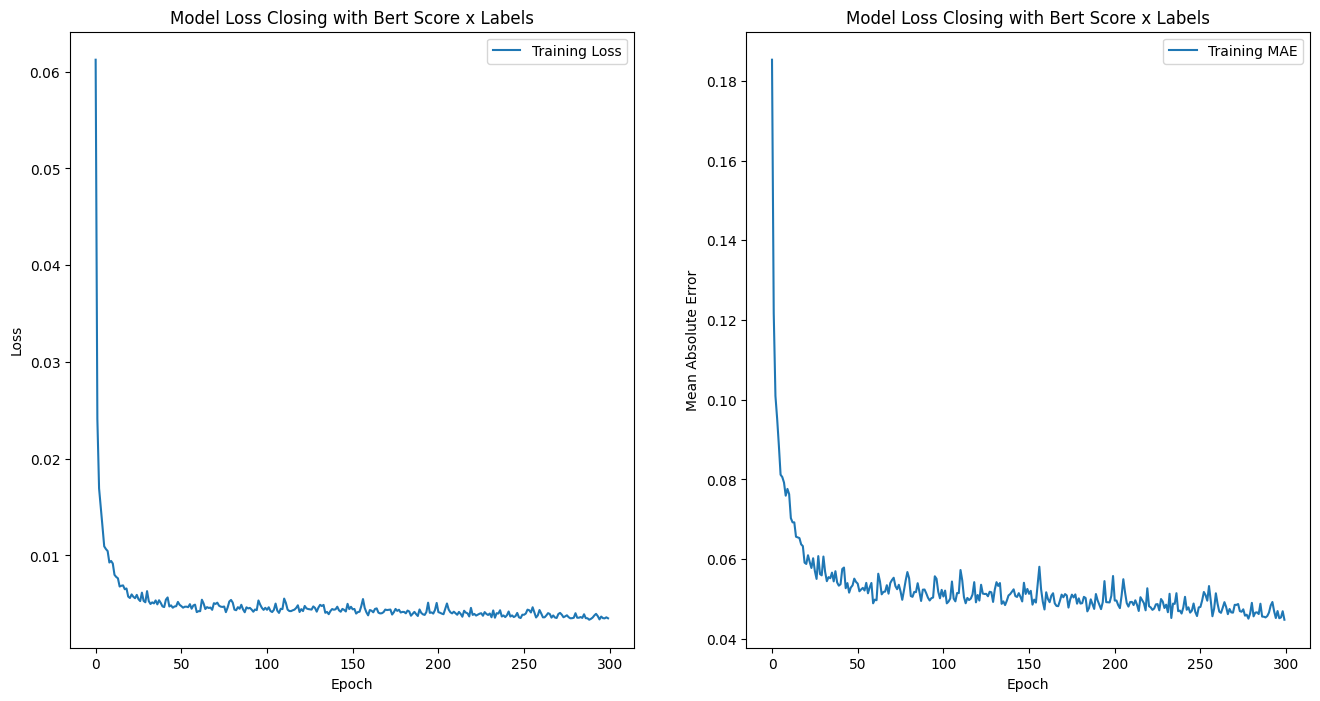

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.plot(history5.history['loss'], label='Training Loss')
plt.title('Model Loss Closing with Bert Score x Labels')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history5.history['mae'], label='Training MAE')
plt.title('Model Loss Closing with Bert Score x Labels')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()

In [ ]:
predictions = model5.predict(X_test)
predictions_concat = np.concatenate((predictions, np.zeros((predictions.shape[0], 2))), axis = 1)
predictions_inverted = x_scaler.inverse_transform(predictions_concat)
predictions = predictions_inverted[:, 0]

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step


In [ ]:
rmse4 = np.sqrt(np.mean(predictions - y_test) ** 2)
print(rmse4)

7.28020574990466


<ipython-input-31-44bf450d4361>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train5['Date'] = dates[:amzn_len]
<ipython-input-31-44bf450d4361>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testing5['Date'] = dates[amzn_len:]
<ipython-input-31-44bf450d4361>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/in

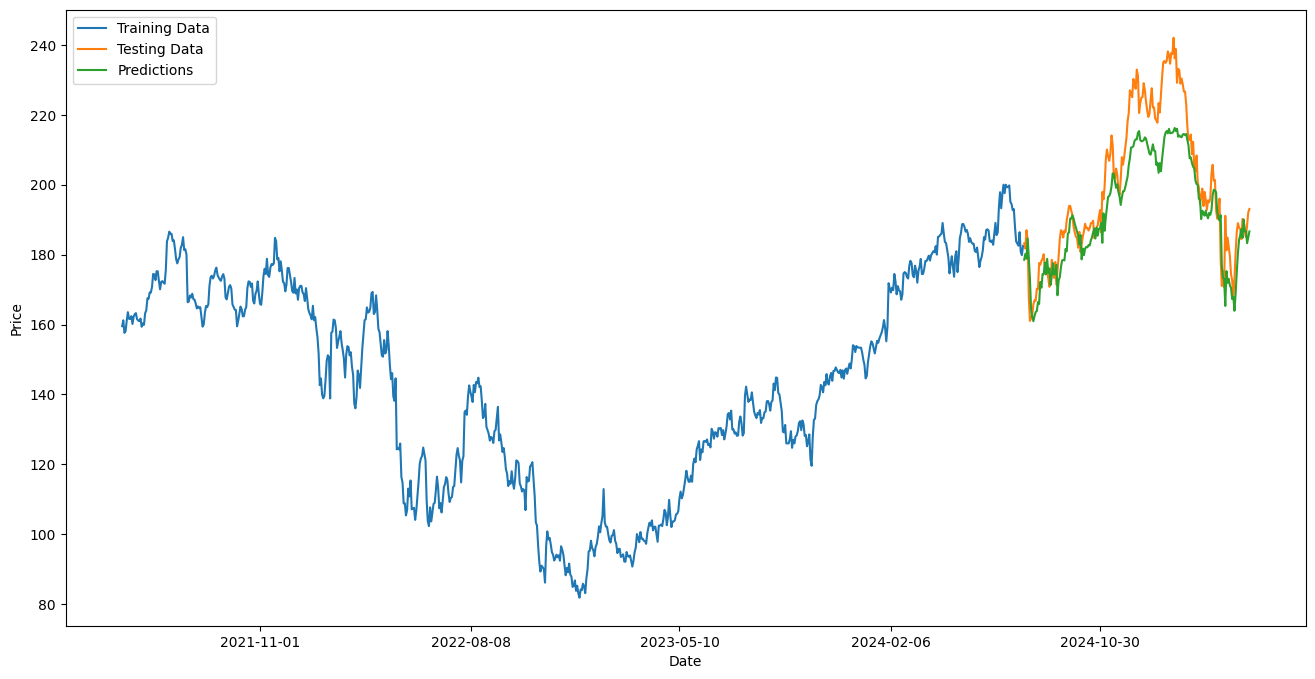

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
train5 = amzn_data[:amzn_len]
train5['Date'] = dates[:amzn_len]
testing5 = amzn_data[amzn_len:]
testing5['Date'] = dates[amzn_len:]
testing5['Predictions']= predictions

plt.figure(figsize=(16,8))
plt.plot(train5['Date'],train5['Close'], label = "Training Data")
plt.plot(testing5['Date'],testing5['Close'], label = "Testing Data")
plt.plot(testing5['Date'], testing5['Predictions'], label ="Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

# **Comparison Between models**

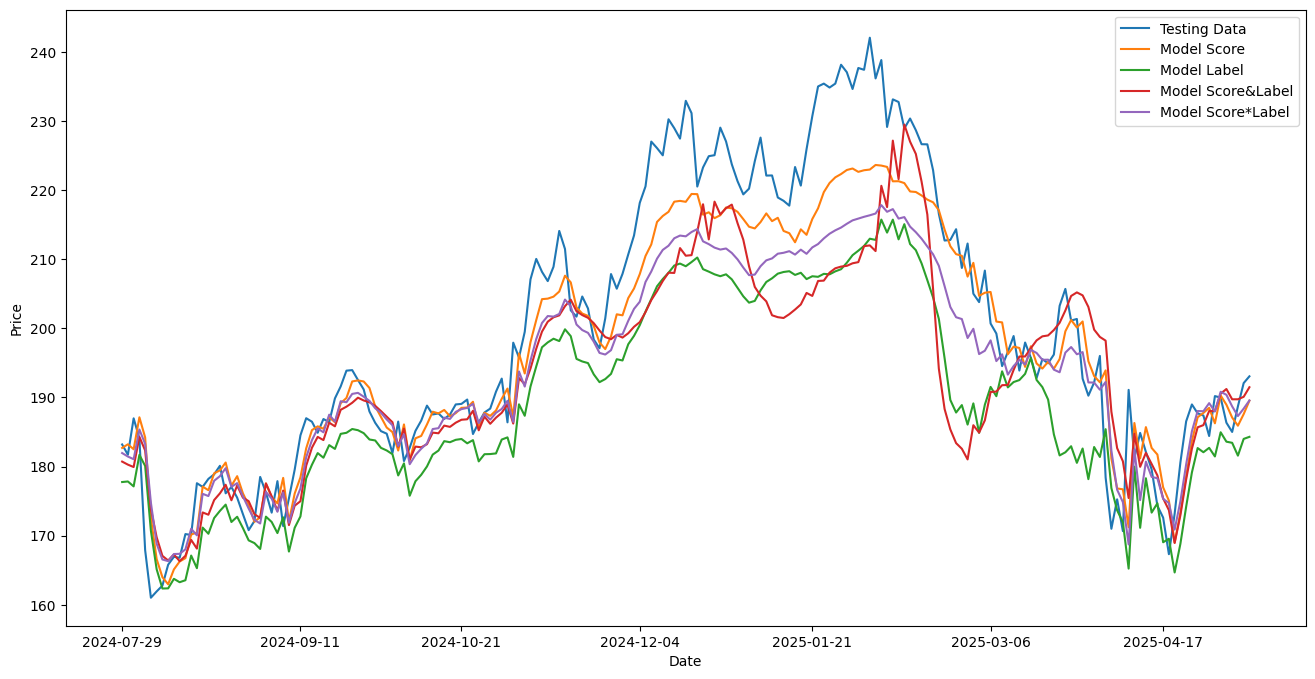

In [ ]:
plt.figure(figsize=(16,8))
plt.plot(testing['Date'],testing['Close'], label = "Testing Data")
plt.plot(testing['Date'], testing['Predictions'], label ="Model Score")

plt.plot(testing2['Date'],testing2['Predictions'], label = "Model Label")
plt.plot(testing3['Date'],testing3['Predictions'], label = "Model Score&Label")
plt.plot(testing4['Date'], testing4['Predictions'], label ="Model Score*Label")
plt.plot(testing5['Date'], testing5['Predictions'], label ="Model Difference&Score")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

In [ ]:
!pip install -q joblib

In [ ]:
PROJECT_FOLDER = "/content/gdrive/MyDrive/Colab Notebooks/Thesis/Models"
os.chdir(PROJECT_FOLDER)
print(os.getcwd())

/content/gdrive/MyDrive/Colab Notebooks/Thesis/Models


In [ ]:
import joblib
joblib.dump(model1,"BERT_Model1")
joblib.dump(model2, "BERT_Model2")
joblib.dump(model3, "BERT_Model3")
joblib.dump(model4, "BERT_Model4")
joblib.dump(model5, "BERT_Model5")

['BERT_Model5']